In [1]:
!pip install -q chromadb sentence-transformers groq langchain \
    langchain-community biopython pandas matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.0/23.0 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 77.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 89.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 

In [2]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

In [3]:
from Bio import Entrez
import pandas as pd
import time

Entrez.email = "your.email@gmail.com"  # put your real email

def fetch_pubmed_abstracts(query, max_results=500):
    # Search PubMed
    handle = Entrez.esearch(db="pubmed", term=query, retmax=max_results)
    record = Entrez.read(handle)
    handle.close()
    ids = record["IdList"]
    print(f"Found {len(ids)} articles")

    # Fetch abstracts in batches
    abstracts = []
    batch_size = 50
    for i in range(0, len(ids), batch_size):
        batch = ids[i:i+batch_size]
        handle = Entrez.efetch(db="pubmed", id=batch,
                               rettype="abstract", retmode="xml")
        records = Entrez.read(handle)
        handle.close()

        for article in records["PubmedArticle"]:
            try:
                title = str(article["MedlineCitation"]["Article"]["ArticleTitle"])
                abstract_texts = article["MedlineCitation"]["Article"].get(
                    "Abstract", {}).get("AbstractText", [])
                abstract = " ".join([str(a) for a in abstract_texts])
                year = str(article["MedlineCitation"]["Article"][
                    "Journal"]["JournalIssue"]["PubDate"].get("Year", "Unknown"))
                pmid = str(article["MedlineCitation"]["PMID"])

                if abstract.strip():
                    abstracts.append({
                        "pmid": pmid,
                        "title": title,
                        "abstract": abstract,
                        "year": year
                    })
            except Exception:
                continue
        time.sleep(0.5)  # be polite to the API

    return pd.DataFrame(abstracts)

# Fetch abstracts - these queries are clinically specific and relevant to LCSB
queries = [
    "Parkinson's disease machine learning biomarkers",
    "Parkinson's disease electronic health records NLP",
    "Parkinson's disease multimodal data deep learning",
    "Alzheimer's disease clinical data harmonisation OMOP"
]

all_dfs = []
for q in queries:
    df = fetch_pubmed_abstracts(q, max_results=150)
    df["query"] = q
    all_dfs.append(df)
    print(f"Query: '{q}' → {len(df)} abstracts")

corpus = pd.concat(all_dfs).drop_duplicates(subset="pmid").reset_index(drop=True)
print(f"\nTotal unique abstracts: {len(corpus)}")
corpus.head(3)

Found 150 articles
Query: 'Parkinson's disease machine learning biomarkers' → 149 abstracts
Found 1 articles
Query: 'Parkinson's disease electronic health records NLP' → 1 abstracts
Found 84 articles
Query: 'Parkinson's disease multimodal data deep learning' → 84 abstracts
Found 0 articles
Query: 'Alzheimer's disease clinical data harmonisation OMOP' → 0 abstracts

Total unique abstracts: 225


,pmid,title,abstract,year,query
0,41948713,Enhancing Early Diagnosis: Multimodal AI Appro...,Neurodegenerative diseases such as Alzheimer's...,2026,Parkinson's disease machine learning biomarkers
1,41942436,Quantitative susceptibility mapping and MRS-ba...,"Parkinson's disease (PD) is a complex, progres...",2026,Parkinson's disease machine learning biomarkers
2,41930586,AI-Driven Biomarker Discovery in Motor-Related...,"Parkinson's disease (PD), Huntington's disease...",2026,Parkinson's disease machine learning biomarkers


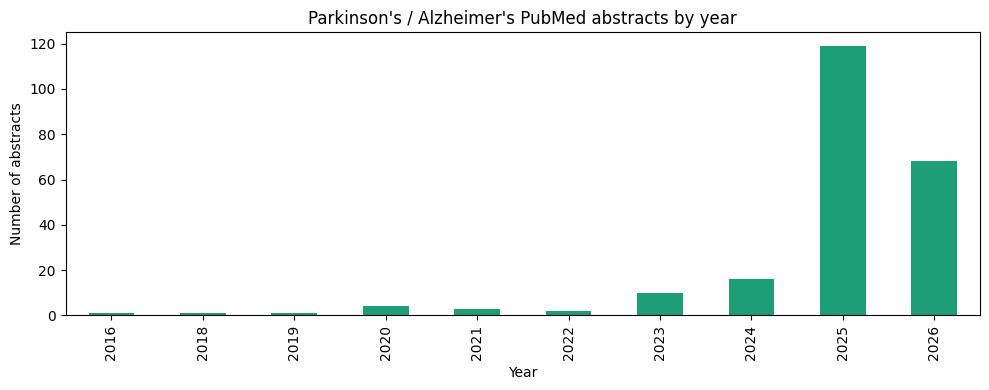

Abstract length stats:
count    225.000000
mean     244.502222
std       63.728436
min      120.000000
25%      199.000000
50%      241.000000
75%      282.000000
max      478.000000
Name: abstract, dtype: float64


In [4]:
import matplotlib.pyplot as plt

# Year distribution
corpus["year"] = pd.to_numeric(corpus["year"], errors="coerce")
corpus_clean = corpus.dropna(subset=["year"])

plt.figure(figsize=(10, 4))
corpus_clean["year"].value_counts().sort_index().plot(kind="bar", color="#1D9E75")
plt.title("Parkinson's / Alzheimer's PubMed abstracts by year")
plt.xlabel("Year")
plt.ylabel("Number of abstracts")
plt.tight_layout()
plt.savefig("abstracts_by_year.png", dpi=150)
plt.show()

print(f"Abstract length stats:\n{corpus['abstract'].str.split().str.len().describe()}")

In [5]:
corpus.to_csv("parkinsons_abstracts.csv", index=False)
print(f"Saved {len(corpus)} abstracts")

Saved 225 abstracts


In [7]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=400,
    chunk_overlap=50,
    separators=["\n\n", "\n", ". ", " "]
)

chunks = []
for _, row in corpus.iterrows():
    text = f"Title: {row['title']}\n\n{row['abstract']}"
    split_texts = splitter.split_text(text)
    for i, chunk in enumerate(split_texts):
        chunks.append({
            "chunk_id": f"{row['pmid']}_{i}",
            "pmid": row["pmid"],
            "text": chunk,
            "title": row["title"],
            "year": str(row["year"])
        })

print(f"Total chunks: {len(chunks)}")
print(f"\nExample chunk:\n{chunks[0]['text']}")

Total chunks: 1639

Example chunk:
Title: Enhancing Early Diagnosis: Multimodal AI Approaches for Neurodegenerative Diseases.


In [8]:
from sentence_transformers import SentenceTransformer
import chromadb

# Bio_ClinicalBERT - trained on MIMIC clinical notes, perfect for this use case
print("Loading clinical embedding model...")
embedder = SentenceTransformer("emilyalsentzer/Bio_ClinicalBERT")

# Embed in batches
texts = [c["text"] for c in chunks]
print(f"Embedding {len(texts)} chunks...")
embeddings = embedder.encode(texts, batch_size=32, show_progress_bar=True)
print(f"Embedding shape: {embeddings.shape}")

# Store in ChromaDB
client = chromadb.Client()
collection = client.create_collection(
    name="parkinsons_literature",
    metadata={"hnsw:space": "cosine"}
)

# Add in batches of 100
batch_size = 100
for i in range(0, len(chunks), batch_size):
    batch_chunks = chunks[i:i+batch_size]
    batch_embeddings = embeddings[i:i+batch_size]
    collection.add(
        ids=[c["chunk_id"] for c in batch_chunks],
        embeddings=batch_embeddings.tolist(),
        documents=[c["text"] for c in batch_chunks],
        metadatas=[{"pmid": c["pmid"], "title": c["title"],
                    "year": c["year"]} for c in batch_chunks]
    )

print(f"Stored {collection.count()} chunks in ChromaDB")

Loading clinical embedding model...


BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding 1639 chunks...


Embedding shape: (1639, 768)
Stored 1639 chunks in ChromaDB


In [10]:
from groq import Groq
from google.colab import userdata

# Store key: Runtime > Secrets > add GROQ_API_KEY
client_groq = Groq(api_key=userdata.get('GROQ_API_KEY'))

def retrieve(query, n_results=5):
    query_embedding = embedder.encode([query])[0]
    results = collection.query(
        query_embeddings=[query_embedding.tolist()],
        n_results=n_results,
        include=["documents", "metadatas", "distances"]
    )
    return results

def generate_answer(query, retrieved_results):
    docs = retrieved_results["documents"][0]
    metas = retrieved_results["metadatas"][0]
    distances = retrieved_results["distances"][0]

    context_parts = []
    for doc, meta, dist in zip(docs, metas, distances):
        similarity = round(1 - dist, 3)
        context_parts.append(
            f"[Source: PMID {meta['pmid']} | {meta['year']} | "
            f"Similarity: {similarity}]\n{doc}"
        )
    context = "\n\n---\n\n".join(context_parts)

    system_prompt = """You are a clinical research assistant specialising in
neurodegeneration. Answer questions using only the provided research abstracts.
Always cite the PMID of sources you use. If the context does not contain
enough information, say so clearly."""

    response = client_groq.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content":
             f"Context:\n{context}\n\nQuestion: {query}"}
        ],
        temperature=0.1,
        max_tokens=600
    )
    return response.choices[0].message.content

def rag_pipeline(query, n_results=5):
    print(f"Query: {query}\n")
    retrieved = retrieve(query, n_results)
    answer = generate_answer(query, retrieved)
    print(f"Answer:\n{answer}\n")
    print(f"Sources used:")
    for meta, dist in zip(retrieved["metadatas"][0], retrieved["distances"][0]):
        print(f"  PMID {meta['pmid']} ({meta['year']}) — "
              f"similarity: {round(1-dist, 3)}")
    return answer

In [ ]:
from google.colab import userdata
userdata.get('secretName')

In [11]:
test_queries = [
    "What machine learning methods have been used to predict Parkinson's disease progression?",
    "How have NLP techniques been applied to clinical notes for Parkinson's diagnosis?",
    "What biomarkers are used for early detection of Parkinson's disease?",
    "How is multimodal data integrated for Alzheimer's disease research?",
    "What are the challenges of harmonising clinical data across hospitals for neurodegenerative disease research?"
]

results_log = []
for query in test_queries:
    print("="*60)
    answer = rag_pipeline(query)
    results_log.append({"query": query, "answer": answer})
    print()

Query: What machine learning methods have been used to predict Parkinson's disease progression?

Answer:
Based on the provided research abstracts, the following machine learning methods have been used to predict Parkinson's disease progression:

1. Random Forest (PMID 41487420, 2025) - This method emerged as the most reliable approach for predicting cognitive impairment in Parkinson's disease, integrating multimodal clinical and neuropsychological data.

2. Machine learning models (PMID 41291525, 2025) - This study used machine learning methods with selected multiple serological biomarkers to predict motor symptom severity and stage classification in Parkinson's disease.

3. Deep learning methods (PMID 40704399, 2025) - These methods, combined with magnetic resonance imaging (MRI) data, have shown great potential in aiding automatic diagnosis, particularly in differentiating between multiple system atrophy (MSA) and Parkinson's disease.

Note: The abstracts do not provide a comprehensi

In [12]:
import numpy as np

def evaluate_retrieval(queries, k_values=[1, 3, 5]):
    """Evaluate retrieval at different k values using similarity scores"""
    results = []
    for query in queries:
        query_embedding = embedder.encode([query])[0]
        retrieved = collection.query(
            query_embeddings=[query_embedding.tolist()],
            n_results=max(k_values),
            include=["distances", "metadatas"]
        )
        distances = retrieved["distances"][0]
        similarities = [round(1 - d, 4) for d in distances]

        for k in k_values:
            avg_sim = np.mean(similarities[:k])
            results.append({
                "query": query[:60] + "...",
                f"avg_similarity@{k}": round(avg_sim, 4)
            })

    return pd.DataFrame(results)

eval_df = evaluate_retrieval(test_queries)
print(eval_df.to_string())
eval_df.to_csv("retrieval_evaluation.csv", index=False)

                                                              query  avg_similarity@1  avg_similarity@3  avg_similarity@5
0   What machine learning methods have been used to predict Park...            0.9348               NaN               NaN
1   What machine learning methods have been used to predict Park...               NaN            0.9327               NaN
2   What machine learning methods have been used to predict Park...               NaN               NaN            0.9320
3   How have NLP techniques been applied to clinical notes for P...            0.9396               NaN               NaN
4   How have NLP techniques been applied to clinical notes for P...               NaN            0.9384               NaN
5   How have NLP techniques been applied to clinical notes for P...               NaN               NaN            0.9366
6   What biomarkers are used for early detection of Parkinson's ...            0.9380               NaN               NaN
7   What biomarkers are 

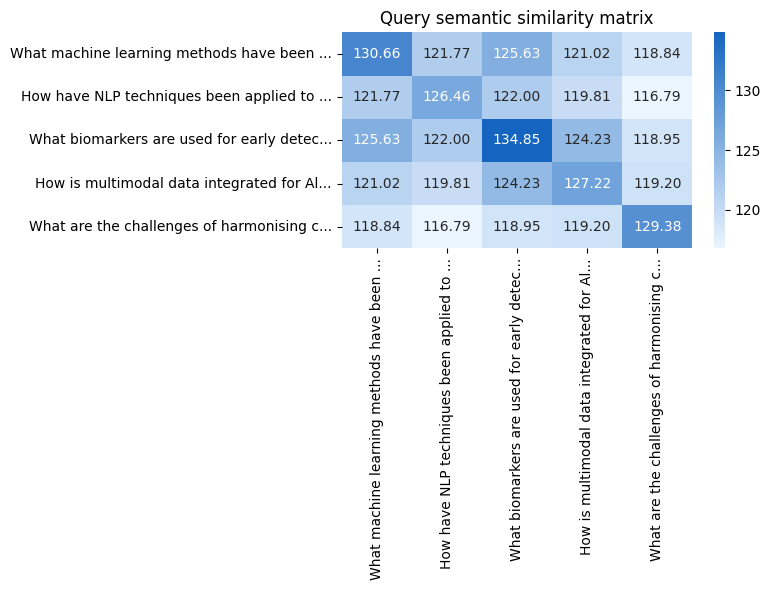

In [18]:
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import numpy as np

custom_blue = LinearSegmentedColormap.from_list(
    "custom_blue", ["#EBF5FF", "#1565C0"]
)

# Normalise embeddings first so values are 0-1
query_embeddings = embedder.encode(test_queries)
norms = np.linalg.norm(query_embeddings, axis=1, keepdims=True)
query_embeddings_norm = query_embeddings / norms
similarity_matrix = np.inner(query_embeddings_norm, query_embeddings_norm)

# Wrap labels properly — no truncation
short_queries = [
    "ML methods for\nParkinson's progression",
    "NLP on clinical notes\nfor Parkinson's",
    "Biomarkers for early\nParkinson's detection",
    "Multimodal data for\nAlzheimer's research",
    "Challenges of\nclinical data harmonisation"
]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    similarity_matrix,
    annot=True,
    fmt=".2f",
    xticklabels=short_queries,
    yticklabels=short_queries,
    cmap=custom_blue,
    vmin=0.7,   # tighten range so colour contrast is visible
    vmax=1.0,
    ax=ax,
    annot_kws={"size": 10}
)
ax.set_title("Query semantic similarity matrix", pad=20, fontsize=13)
ax.tick_params(axis='x', labelsize=9, rotation=30)
ax.tick_params(axis='y', labelsize=9, rotation=0)
plt.tight_layout()
plt.savefig("query_similarity_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()